The Hall Effect was discovered by Edwin Hall by experimenting with Maxwell's equations of electricity and magnetism. He discovered that a magnetic field perpendicular to the direction of a current would result in small but measurable potential difference which was perpendicular again to both the direction of the current and the direction of the magnetic field. 

To simulate this effect, I will use Python's matplotlib to create a virtual space and populate it with several particles. These particles will have masses and randomized position and velocity vectors as well as randomized charges ($\pm e$). To simulate the effect in a diffuse plasma, particles with positive charge will be given the mass of protons while negatively charged particles will be given the electron mass. The particles with negative charges will be colored red while positive will be colored red. This will allow for particles to have their acceleration and thus their velocities calculated each time step following $F=ma$, where $F$ will be the combined electric, magnetic, and Lorentz forces. To simulate the effect in a solid metal, only negative charges will be generated with the electron masses, while the metal lattice of protons will be implied. 

An external electric field will be applied to simulate a current going from one side of the plot to the other, and an external magnetic field will be applied to induce the Hall effect through Lorentz forces. It will be possible to use only the calculations from the applied fields or to include the forces caused by all other particles in the simulation, although the latter option will heavily affect simulation speed.

# Relevant equations

## Electric field generated by a point particle:
$$ \overrightarrow{E} = \frac{1}{4 \pi \epsilon_0} \frac{q}{r^3} \overrightarrow{r}$$
Where:

$\epsilon_0 = 8.854$ $C^2$ $N$ $m^{-2}$ is the vacuum permittivity,

$q$ is the charge of the particle,

$r$ is the magnitude of the distance from the particle,

$\overrightarrow{r}$ is the position vector from the particle to the point of observation ($\overrightarrow{r}_{obs}-\overrightarrow{r}_{source}$)

### Electric force between two charged particles:
$$\overrightarrow{F_E} = q \overrightarrow{E}$$

## Magnetic field generated by moving charges:
$$\overrightarrow{B}=\frac{\mu_0}{4\pi}\frac{q \overrightarrow{v}\times\overrightarrow{r}}{\overrightarrow{r}^3}$$

Where:

$\mu_0 = 1.257 \times 10^{-7}$ $N s^2$ $C^{-2}$ is the vacuum permaebility,

$\overrightarrow{v}$ is the particle's velocity vector, and

$\overrightarrow{r}$ is the particle's position vector

### Magnetic Force
$$\overrightarrow{F_B} = q\overrightarrow{v} \times \overrightarrow{B}$$

## Lorentz Force

$$\overrightarrow{F_L} = q(\overrightarrow{E} + \overrightarrow{v} \times \overrightarrow{B})$$

In order to simulate all of these effects then, every particle must know at each time step:

1. Its mass
2. Its position vector
3. Its velocity vector
4. Its charge

These four values can then be used to find the forces acting on each particle, allowing the position and velocity vectors to be updated the next time step. The first step is to create methods for each of these equations to be called during simulation.

In [29]:
from IPython.display import display, clear_output

import matplotlib.pyplot as plt
import numpy as np

# Define constants
epsilon_0 = 8.85e-12  # C^2 N^-1 m^-2
mu_0      = 1.257e-7  # N s^2 C^-2
q         = 1.602e-19 # C
m_e       = 9.11e-31  # electron mass (kg)
m_p       = 1.672e-27  # proton mass (kg)
k         = 1 / (4 * np.pi * epsilon_0)

# Define functions
def calc_magnitude(vector):
    return np.linalg.norm(vector)

def to_3d(vec_2d):
    return np.array([vec_2d[0], vec_2d[1], 0.0])

def to_2d(vec_3d):
    return(vec_3d[:2])

def calc_e_field(q, r_vec):
    r_vec = np.asarray(r_vec)
    r_mag = calc_magnitude(r_vec)
    return (1/ (4 * np.pi * epsilon_0)) * (q * r_vec) / (r_mag**3)

def calc_e_force(q, e_field):
    e_field = np.asarray(e_field)
    return q * e_field

def calc_b_field(q, v_vec, r_vec):
    v_vec = np.asarray(v_vec)
    r_vec = np.asarray(r_vec)
    r_mag = calc_magnitude(r_vec)
    return (mu_0 / (4 * np.pi)) * (q * (np.cross(v_vec, r_vec))/(r_mag **3))

def calc_b_force(q, v_vec, b_field):
    v_vec   = np.asarray(v_vec)
    b_field = np.asarray(b_field )
    return q * np.cross(v_vec, b_field)

def calc_lorentz_force(q, v_vec, E_field, B_field):
    return q * ((E_field) + (np.cross(v_vec, B_field)))

# Time steps
This animation has the option to update using either Euler or Runge-Kutta approximations. For both of these approximations, it is important to know the instantaneous position, velocity, and acceleration of every particle. As $\overrightarrow{F}=m\overrightarrow{a} \to \overrightarrow{a} = \overrightarrow{F}/m$, the acceleration can be found using the calculated Lorentz force on a particle and dividing this force by the particle's mass. The velocity and position are updated with a slightly different method between Euler and Runge-Kutta.

## Euler approximation
This works by updating the velocity and the positions of particles at each time step $dt$ using:

$$\overrightarrow{v}_{i+1} = \overrightarrow{v}_i + (\overrightarrow{a} * dt)$$
$$\overrightarrow{r}_{i+1} = \overrightarrow{r}_i + (\overrightarrow{v}_i * dt)$$

## Runge-Kutta approximation
This approximation is performed to the fourth order as:
$$\overrightarrow{y}_{i+1} = y_i + (k_1 + 2k_2 + 2k_2 +k_4) * \frac{dt}{6}$$
Here, $k_1 \to k_4$ are found for a function $f(t_n, y_n)$ as:

$k_1 = f(t_n, y_n)$,

$k_2 = f(t_n + \frac{dt}{2}, y_n + k_1 \frac{dt}{2})$,

$k_3 = f(t_n + \frac{dt}{2}, y_n + k_2 \frac{dt}{2})$,

$k_4 = f(t_n + \frac{dt}{2}, y_n + dt k_3)$

The Euler method is faster as it only offers a first order approximation, while Runge-Kutta samples the slopes of the position and velocity vectors at multiple points, allowing for a more accurate approximation at the cost of some speed. Either method of approximation can be chosen while running the simulation.

In [30]:
# Runge-Kutta functions
def derivatives(v, q, m, E_field, B_field):
    """
    E_field and B_field are the total fields experienced by a particle, not just the external fields.
    This function can then be used to calculate the acceleration due to the Lorentz force
    """
    drdt = v
    L_force = calc_lorentz_force(q, v, E_field, B_field)
    dvdt = L_force / m

    return drdt, dvdt

def runge_kutta_update(r, v, q, m, E_field, B_field, dt):
    
    k1_r, k1_v = derivatives(v, q, m, E_field, B_field)

    k2_r, k2_v = derivatives(
        v + (dt * k1_v)/2,
        q, m, E_field, B_field
    )

    k3_r, k3_v = derivatives(
        v + (dt * k2_v)/2,
        q, m, E_field, B_field
    )

    k4_r, k4_v = derivatives(
        v + (dt * k3_v),
        q, m, E_field, B_field
    )

    ri = r + ((dt/6) * (k1_r + (2 * k2_r) + (2 * k3_r) + k4_r))
    vi = v + ((dt/6) * (k1_v + (2 * k2_v) + (2 * k3_v) + k4_v))

    return ri, vi

def euler_update(r, v, q, m, E_field, B_field, dt):
    _, a = derivatives(v, q, m, E_field, B_field)

    vi = v + (a * dt)
    ri = r + (vi * dt)

    return ri, vi

# Creating simulation

In [31]:
def run_sim(
        # Inital conditions
        positions, velocities, E_ext, B_ext, 
        # Sim properties
        container_size, colors, num_particles, charges, masses,
        # Time properties
        dt, time_steps,
        # Update method
        method="euler", particle_phys=True
):
    # Create plot
    fig, ax = plt.subplots()
    scatter = ax.scatter(positions[:, 0], positions[:, 1], c=colors, marker='o')
    ax.set_xlim(0, container_size)
    ax.set_ylim(0, container_size)
    plt.gca().set_aspect('equal', adjustable='box')
    
    # Run sim
    for step in range(time_steps):
        new_positions  = np.zeros_like(positions)
        new_velocities = np.zeros_like(velocities)

        for i in range(num_particles):
            r_i = to_3d(positions[i])
            v_i = to_3d(velocities[i])

            E_total = np.copy(E_ext)
            B_total = np.copy(B_ext)

            # Sum contributions from all other particles
            for j in range(num_particles):
                if i == j:
                    continue

                r_vec = r_i - to_3d(positions[j])
                r_mag = calc_magnitude(r_vec)
                if r_mag == 0:
                    continue

                if particle_phys:
                    E_total += calc_e_field(charges[j], r_vec)
                    B_total += calc_b_field(charges[j], to_3d(velocities[j]), r_vec)

            # Update using Euler method
            if method.lower() == "euler":
                r_new, v_new = euler_update(r_i, v_i, charges[i], masses[i], E_total, B_total, dt)
            elif method.lower() == "runge-kutta":
                # Update using runge kutta
                r_new, v_new = runge_kutta_update(r_i, v_i, charges[i], masses[i], E_total, B_total, dt)
            else:
                raise ValueError("Method must be 'Euler' or 'Runge-Kutta.'")

            new_positions[i] = to_2d(r_new)
            new_velocities[i] = to_2d(v_new)

        positions = new_positions
        velocities = new_velocities

        # Collide with plot walls and absorb energy
        # Allow current flow
        for i in range(num_particles):
            # Move charges that escape to opposite side of plot
            if positions[i, 0] < 0:
                positions[i, 0] += container_size
            elif positions[i, 0] > container_size:
                positions[i, 0] -= container_size

            # Reflect off y walls
            if positions[i, 1] < 0:
                positions[i, 1] = -positions[i, 1]
                velocities[i, 1] *= -1

            elif positions[i, 1] > container_size:
                positions[i, 1] = 2 * container_size - positions[i, 1]
                velocities[i, 1] *= -1

        scatter.set_offsets(positions)
        plt.title(f"Time: {dt * step:.2e} s ({method} time steps)")
        plt.xlabel(f'Width (m)')
        plt.ylabel(f'Height (m)')
        clear_output(wait=True)
        display(fig)

# Running simulation: Diffuse plasma
The following simulation demonstrates the Hall effect in a high energy plasma with an applied current and magnetic field. 

In this scenario, while a visible voltage does appear perpendicular to the two applied fields for some time, if the simulation were ran for long enough, this voltage would eventually disappear. This is because the current causes the protons and the electrons to have opposite velocities. As they also have opposite charges, this would eventually cause them to deflect to the same side of the plot, dropping the voltage. The only thing preventing this from happening in the time scales of this plot is the difference in masses between electrons and protons. As protons are much more massive than electrons, they have much more inertia from their initial randomized velocities which takes more time to cancel out using Lorentz forces.

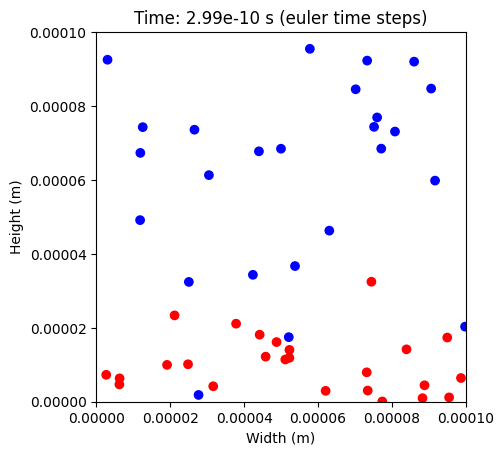

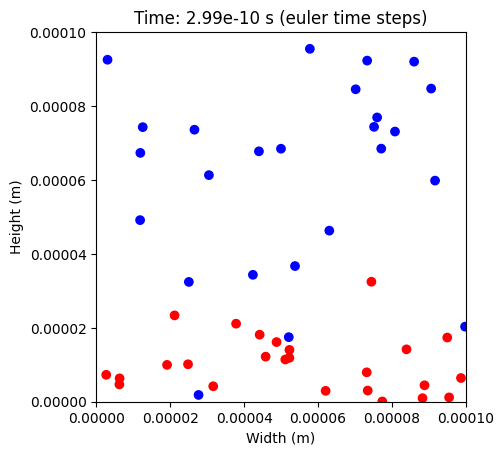

In [36]:
# Create initial conditions
num_particles = 50
particle_speed = 1e6 # m/s

# Simulation parameters
container_size = 1e-4  # m
time_steps     = 300
dt             = 1e-12 # s

# Define fields
E_ext = np.array([1e5, 0.0, 0.0]) # N/C
B_ext = np.array([0.0, 0.0, 2e-1])  # T

# Initial particle conditions
positions  = np.random.rand(num_particles, 2) * container_size
velocities = (np.random.rand(num_particles, 2)-0.5) * particle_speed
charges    = np.random.choice([-1, 1], size=num_particles) * q
masses     = np.where(charges > 0, m_p, m_e)
colors     = np.where(charges > 0, 'blue', 'red')
run_sim(
    positions, velocities, E_ext, B_ext, 
    # Sim properties
    container_size, colors, num_particles, charges, masses,
    # Time properties
    dt, time_steps,
    "euler", False
)

# Running simulation: Metal lattice
In a physical scenario, the Hall effect is usually observed in solid metals instead of plasmas. In solids, the protons are held in a tight lattice while the electrons are free to move throughout the material. This generates a voltage perpendicular to the applied fields as above, but in a way that would last the entire duration that the fields are applied as the protons are not free to move. This can be approximated using this simulator by only allowing for one charge and one mass and assuming a positive charge throughout the material otherwise.

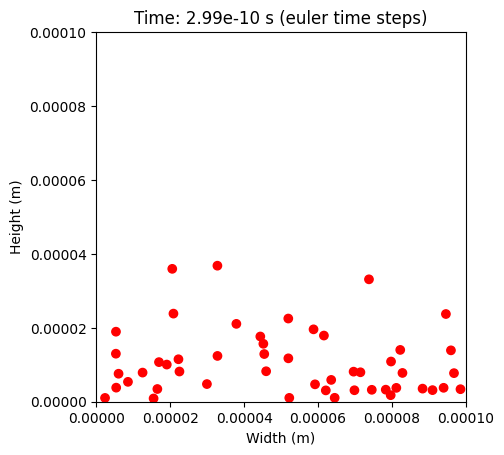

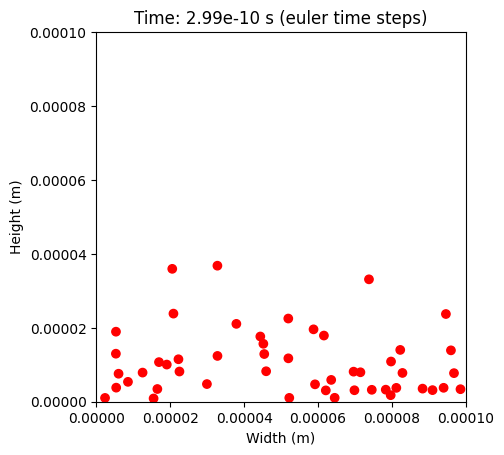

In [37]:
charges    = np.full(num_particles, -q)
masses     = np.full(num_particles, m_e)
colors     = np.full(num_particles, 'red')
run_sim(
    positions, velocities, E_ext, B_ext, 
    # Sim properties
    container_size, colors, num_particles, charges, masses,
    # Time properties
    dt, time_steps,
    "euler", True
)